# 서울시 자치구 폐기물 조정지표 분석 v2 — 강서구 사례 분리

## v1 → v2 핵심 변경

v1(`05_waste_adjusted_index.ipynb`)에서 강서구가 압도적인 outlier(Cook's D=1.36, 표준화 잔차=4.48)로 회귀선을 좌우.

**v2 설계**
1. **회귀 적합은 24개 자치구로** (강서구 제외) — 일반적 패턴이 회귀선에 정확히 반영되도록
2. **예측·조정지표 산출은 25개 모두** — 강서구도 분류 결과에 포함
3. **강서구는 "모형 외 극단치"로 명시** — 별도 사례 분석 섹션
4. **v1 vs v2 비교 섹션** — 어떻게 달라졌는지 정량화

> 강서구를 "숨기는" 게 아니라 "강서구의 특수성을 데이터로 드러내는" 분석이다.
> 강서구는 사업장+건설 폐기물 비중이 67.9%로 압도적이어서 같은 회귀선에 묶기 부자연스럽다.

**산출**: `data/preprocess/gu_waste_adjusted_v2.csv` (25행 × 11컬럼)

## Step 0. 환경 셋업

라이브러리 임포트, 경로 정의, 한글 폰트, GU_CODE_MAP.

In [1]:
import os, sys, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scistats

warnings.filterwarnings("ignore")
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.max_columns", 50)

# 한글 폰트 폴백
for fn in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    try:
        mpl.rcParams["font.family"] = fn
        mpl.rcParams["axes.unicode_minus"] = False
        break
    except Exception:
        continue

# 경로
NB_DIR     = os.path.abspath(os.getcwd())
PROJ_ROOT  = os.path.abspath(os.path.join(NB_DIR, ".."))
DATA_DIR   = os.path.join(PROJ_ROOT, "data")
PREPROC_DIR = os.path.join(DATA_DIR, "preprocess")
os.makedirs(PREPROC_DIR, exist_ok=True)

print("DATA_DIR   :", DATA_DIR)
print("PREPROC_DIR:", PREPROC_DIR)

GU_CODE_MAP = {
    11110: "종로구",   11140: "중구",     11170: "용산구",   11200: "성동구",
    11215: "광진구",   11230: "동대문구", 11260: "중랑구",   11290: "성북구",
    11305: "강북구",   11320: "도봉구",   11350: "노원구",   11380: "은평구",
    11410: "서대문구", 11440: "마포구",   11470: "양천구",   11500: "강서구",
    11530: "구로구",   11545: "금천구",   11560: "영등포구", 11590: "동작구",
    11620: "관악구",   11650: "서초구",   11680: "강남구",   11710: "송파구",
    11740: "강동구",
}
assert len(GU_CODE_MAP) == 25

# 분류별 색상 (v1과 일관성 유지)
CLS_COLOR = {
    "과다": "#dc2626",
    "주의": "#f59e0b",
    "적정": "#16a34a",
    "양호": "#0ea5e9",
    "우수": "#1d4ed8",
}
print("GU_CODE_MAP: 25개 매핑")

DATA_DIR   : D:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data
PREPROC_DIR: D:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess
GU_CODE_MAP: 25개 매핑


**검증 — Step 0**: 라이브러리 버전 + 필수 5개 파일 + v1 결과(선택) 확인.

In [2]:
import statsmodels
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("statsmodels:", statsmodels.__version__)
print()

REQUIRED = {
    "분류 결과":       os.path.join(PREPROC_DIR, "gu_classified.csv"),
    "폐기물(daily)":   os.path.join(PREPROC_DIR, "per_capita.csv"),
    "사업체 xlsx":     os.path.join(DATA_DIR, "사업체현황_2024.xlsx"),
    "생활인구 csv":    os.path.join(DATA_DIR, "생활인구_2024.csv"),
    "폐기물 4분류":    os.path.join(PREPROC_DIR, "recycle_industry.csv"),  # NEW
}
missing = []
for label, p in REQUIRED.items():
    ok = os.path.exists(p)
    print(f"  [{'OK' if ok else 'MISSING'}] {label:14s} {os.path.basename(p)}")
    if not ok: missing.append(label)
if "분류 결과" in missing:
    raise FileNotFoundError("gu_classified.csv 없음. 04_classify_gu_4type.ipynb 먼저 실행.")
if missing:
    raise FileNotFoundError(f"누락 파일: {missing}")
print()

# v1 결과(선택)
V1_PATH = os.path.join(PREPROC_DIR, "gu_waste_adjusted.csv")
if os.path.exists(V1_PATH):
    df_v1 = pd.read_csv(V1_PATH, encoding="utf-8-sig")
    print(f"  [OK] v1 결과 발견 — Step 9 비교 섹션 활성화 (shape={df_v1.shape})")
else:
    df_v1 = None
    print("  [INFO] v1 결과 없음 — Step 9 비교 섹션 스킵")
print("\n✅ 필수 파일 모두 존재")

pandas     : 2.2.3
numpy      : 2.2.6
statsmodels: 0.14.6

  [OK] 분류 결과          gu_classified.csv
  [OK] 폐기물(daily)     per_capita.csv
  [OK] 사업체 xlsx       사업체현황_2024.xlsx
  [OK] 생활인구 csv       생활인구_2024.csv
  [OK] 폐기물 4분류        recycle_industry.csv

  [OK] v1 결과 발견 — Step 9 비교 섹션 활성화 (shape=(25, 10))

✅ 필수 파일 모두 존재


## Step 1. 통합 테이블 구성 (df_full 25개)

v1과 동일 로직으로 25개 자치구 마스터 테이블 생성.

In [3]:
# 1-1. 분류 결과
gu_class = pd.read_csv(os.path.join(PREPROC_DIR, "gu_classified.csv"),
                       encoding="utf-8-sig")
gu_class = gu_class[["자치구", "거주인구", "유형"]].copy()

# 1-2. 폐기물 daily
df_pc = pd.read_csv(os.path.join(PREPROC_DIR, "per_capita.csv"))
df_pc = df_pc[["district", "daily"]].rename(columns={"district": "자치구"})

# 1-3. 종사자수
raw = pd.read_excel(os.path.join(DATA_DIR, "사업체현황_2024.xlsx"),
                    sheet_name="데이터", skiprows=5, header=None,
                    engine="openpyxl")
raw.columns = [f"col_{i}" for i in range(raw.shape[1])]
raw = raw.rename(columns={"col_0": "동별1", "col_1": "자치구",
                          "col_4": "종사자수"})
if str(raw.iloc[0]["동별1"]).strip() == "합계":
    raw = raw.iloc[1:].copy()
emp_df = raw[["자치구", "종사자수"]].reset_index(drop=True)
emp_df["종사자수"] = emp_df["종사자수"].astype(int)

# 1-4. 평일 14시 평균 인구
USE_COLS = ["stdr_de_id", "tmzon_pd_se", "adstrd_code_se", "tot_lvpop_co"]
df_lv = pd.read_csv(os.path.join(DATA_DIR, "생활인구_2024.csv"),
                    encoding="utf-8-sig", usecols=USE_COLS,
                    dtype={"stdr_de_id": np.int32, "tmzon_pd_se": np.int8,
                           "adstrd_code_se": np.int32, "tot_lvpop_co": np.float32})
df_lv["자치구"] = df_lv["adstrd_code_se"].map(GU_CODE_MAP)
df_lv["날짜"] = pd.to_datetime(df_lv["stdr_de_id"], format="%Y%m%d")
df_lv["is_weekend"] = df_lv["날짜"].dt.weekday >= 5
mask_wd14 = (~df_lv["is_weekend"]) & (df_lv["tmzon_pd_se"] == 14)
lv14 = (df_lv[mask_wd14].groupby("자치구")["tot_lvpop_co"].mean()
        .reset_index().rename(columns={"tot_lvpop_co": "평일14시인구"}))
lv14["평일14시인구"] = lv14["평일14시인구"].astype(float)

# 1-5. 머지 → df_full
df_full = (gu_class
           .merge(df_pc,  on="자치구", how="left")
           .merge(emp_df, on="자치구", how="left")
           .merge(lv14,   on="자치구", how="left"))
df_full["주간유입인구"] = df_full["평일14시인구"] - df_full["거주인구"]
df_full = df_full[["자치구", "유형", "daily", "거주인구",
                   "평일14시인구", "주간유입인구", "종사자수"]]

print("df_full shape:", df_full.shape)
df_full.head()

df_full shape: (25, 7)


,자치구,유형,daily,거주인구,평일14시인구,주간유입인구,종사자수
0,종로구,상업형,270.2,149608,396429.18750,246821.18750,265635
1,중구,상업형,365.0,131214,436703.46875,305489.46875,399960
2,용산구,유동집중형,283.9,217194,304268.25000,87074.25000,157564
3,성동구,혼합형,435.1,281289,361614.31250,80325.31250,201023
4,광진구,유동집중형,293.0,348652,334800.09375,-13851.90625,125475


In [4]:
assert df_full.shape == (25, 7)
assert df_full.isna().sum().sum() == 0
print(f"shape: {df_full.shape}, 결측 0 ✓")
print(f"거주인구 합계: {df_full['거주인구'].sum():>12,}")
print(f"종사자수 합계: {df_full['종사자수'].sum():>12,}")
print(f"daily 합계   : {df_full['daily'].sum():>12,.1f} 톤/일")
print()

gangseo_row = df_full[df_full["자치구"] == "강서구"].iloc[0]
print(f"=== 강서구 daily 확인 ===")
print(f"  daily       : {gangseo_row['daily']:>10,.1f} 톤/일 (예상 1,614.5)")
print(f"  거주인구    : {int(gangseo_row['거주인구']):>10,}")
print(f"  종사자수    : {int(gangseo_row['종사자수']):>10,}")
print(f"  주간유입인구: {int(gangseo_row['주간유입인구']):>10,}")
assert abs(gangseo_row["daily"] - 1614.5) < 1, "강서구 daily 이상"
print("\n✅ Step 1 검증 통과")

shape: (25, 7), 결측 0 ✓
거주인구 합계:    9,597,372
종사자수 합계:    5,772,456
daily 합계   :     10,483.7 톤/일

=== 강서구 daily 확인 ===
  daily       :    1,614.5 톤/일 (예상 1,614.5)
  거주인구    :    562,194
  종사자수    :    312,532
  주간유입인구:    -39,942

✅ Step 1 검증 통과


## Step 2. 강서구 진단 — 왜 outlier인가? ⭐

`recycle_industry.csv`(폐기물 4분류 비중)로 강서구가 다른 자치구와 구조적으로 다른지 검증.

**가설**: 강서구의 daily=1,614.5톤이 비정상적으로 큰 이유는 **사업장계+건설계 폐기물 비중**이 압도적이기 때문.

In [5]:
# 2-1. recycle_industry.csv 로드 (인코딩 자동 감지)
ri_path = os.path.join(PREPROC_DIR, "recycle_industry.csv")
ri_df = None
for enc in ("utf-8", "utf-8-sig", "cp949"):
    try:
        ri_df = pd.read_csv(ri_path, encoding=enc)
        print(f"recycle_industry.csv 로드 성공 (encoding={enc})")
        break
    except UnicodeDecodeError:
        continue
assert ri_df is not None, "recycle_industry.csv 로드 실패"
print("shape:", ri_df.shape)
print("컬럼:", ri_df.columns.tolist())
ri_df.head()

recycle_industry.csv 로드 성공 (encoding=utf-8)
shape: (25, 10)
컬럼: ['district', 'life_gen', 'industry_gen', 'construction_gen', 'designated_gen', 'total', 'life_pct', 'industry_pct', 'construction_pct', 'designated_pct']


,district,life_gen,industry_gen,construction_gen,designated_gen,total,life_pct,industry_pct,construction_pct,designated_pct
0,종로구,98887,2447,173592,5592,280518,35.3,0.9,61.9,2.0
1,중구,133576,25473,301748,2404,463201,28.8,5.5,65.1,0.5
2,용산구,103895,43457,274422,2273,424047,24.5,10.2,64.7,0.5
3,성동구,159245,111943,751281,4947,1027416,15.5,10.9,73.1,0.5
4,광진구,107234,1264,155354,2216,266068,40.3,0.5,58.4,0.8


In [6]:
# 2-2. 강서구 vs 24개 평균 비교
PCT_COLS = ["life_pct", "industry_pct", "construction_pct", "designated_pct"]
PCT_LABEL = {"life_pct": "생활계", "industry_pct": "사업장계",
             "construction_pct": "건설계", "designated_pct": "지정"}

gangseo = ri_df[ri_df["district"] == "강서구"].iloc[0]
others = ri_df[ri_df["district"] != "강서구"]
others_mean = others[PCT_COLS].mean()

compare_tbl = pd.DataFrame({
    "폐기물 분류": [PCT_LABEL[c] for c in PCT_COLS],
    "강서구(%)":   [gangseo[c] for c in PCT_COLS],
    "24개 평균(%)":[others_mean[c] for c in PCT_COLS],
})
compare_tbl["차이(%p)"] = compare_tbl["강서구(%)"] - compare_tbl["24개 평균(%)"]
compare_tbl["배수"] = (compare_tbl["강서구(%)"] /
                       compare_tbl["24개 평균(%)"]).round(2)
print("=== 강서구 vs 24개 평균 (폐기물 4분류 비중) ===")
print(compare_tbl.round(2).to_string(index=False))
print()

# 절대량 비교
print("=== 강서구 폐기물 절대량 ===")
print(f"  total           : {int(gangseo['total']):>10,} 톤")
print(f"  24개 평균 total : {int(others['total'].mean()):>10,} 톤")
print(f"  강서구 / 24평균 : {gangseo['total'] / others['total'].mean():.2f}배")

=== 강서구 vs 24개 평균 (폐기물 4분류 비중) ===
폐기물 분류  강서구(%)  24개 평균(%)  차이(%p)  배수
     생활계       31.8         30.90      0.90  1.03
   사업장계       21.3          4.40     16.90  4.85
     건설계       46.6         63.75    -17.15  0.73
       지정        0.4          0.96     -0.56  0.42

=== 강서구 폐기물 절대량 ===
  total           :  1,858,065 톤
  24개 평균 total :    509,892 톤
  강서구 / 24평균 : 3.64배


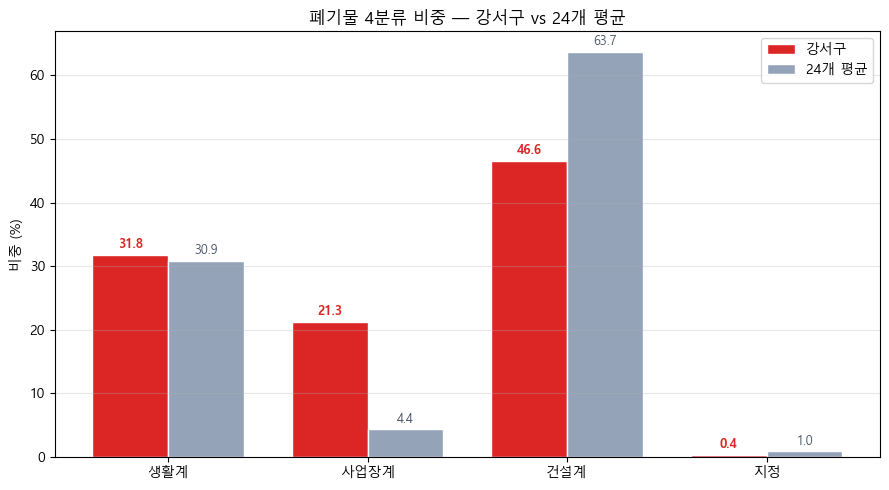

In [7]:
# 2-3. 그룹 막대차트 — 강서구 vs 24개 평균
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(PCT_COLS))
w = 0.38
ax.bar(x - w/2, [gangseo[c] for c in PCT_COLS],
       w, label="강서구", color="#dc2626", edgecolor="white")
ax.bar(x + w/2, [others_mean[c] for c in PCT_COLS],
       w, label="24개 평균", color="#94a3b8", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([PCT_LABEL[c] for c in PCT_COLS])
ax.set_ylabel("비중 (%)")
ax.set_title("폐기물 4분류 비중 — 강서구 vs 24개 평균")
ax.legend()
for i, c in enumerate(PCT_COLS):
    ax.text(i - w/2, gangseo[c] + 1, f"{gangseo[c]:.1f}",
            ha="center", fontsize=9, color="#dc2626", fontweight="bold")
    ax.text(i + w/2, others_mean[c] + 1, f"{others_mean[c]:.1f}",
            ha="center", fontsize=9, color="#475569")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

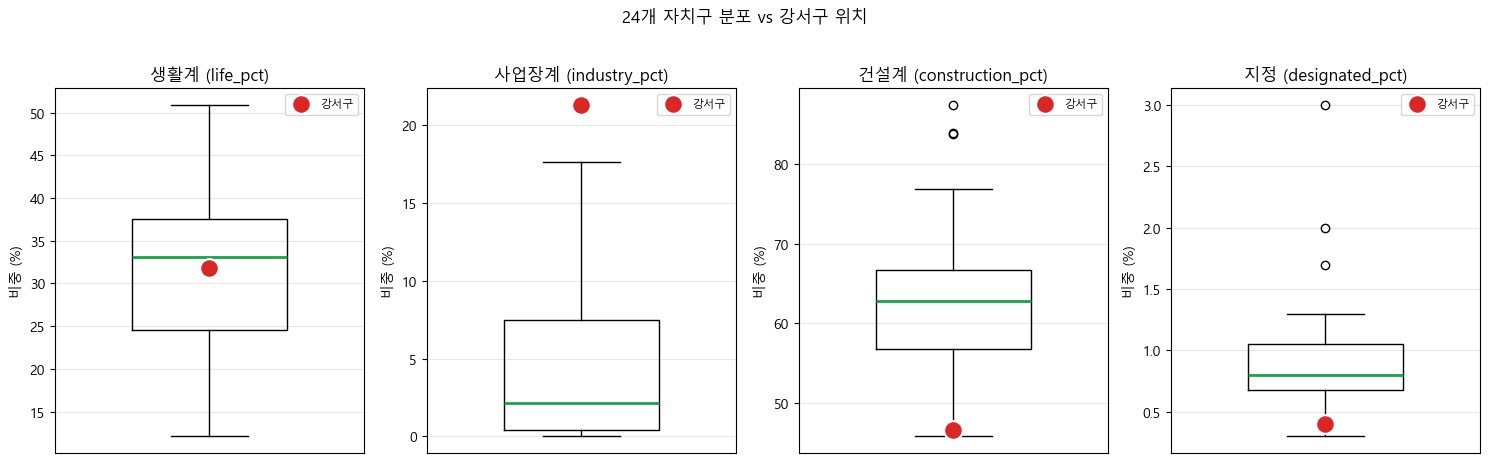

In [8]:
# 2-4. 4분류 비중 자치구 분포 + 강서구 위치 (박스플롯)
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, c in zip(axes, PCT_COLS):
    ax.boxplot(others[c], vert=True, widths=0.5,
               medianprops={"color": "#16a34a", "linewidth": 2})
    ax.scatter([1], [gangseo[c]], color="#dc2626", s=180, zorder=10,
               edgecolor="white", linewidth=1.5, label="강서구")
    ax.set_title(f"{PCT_LABEL[c]} ({c})")
    ax.set_ylabel("비중 (%)")
    ax.set_xticks([])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3, axis="y")
plt.suptitle("24개 자치구 분포 vs 강서구 위치", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
g_industry_construction = gangseo["industry_pct"] + gangseo["construction_pct"]
o_industry_construction = others["industry_pct"].mean() + others["construction_pct"].mean()

print(f"강서구 industry+construction: {g_industry_construction:.1f}%")
print(f"24개 평균 industry+construction: {o_industry_construction:.1f}%")
print()

# 강서구 daily가 24개 평균의 몇 배?
others_daily_mean = df_full[df_full["자치구"] != "강서구"]["daily"].mean()
ratio = gangseo_row["daily"] / others_daily_mean
print(f"강서구 daily : {gangseo_row['daily']:>8,.1f} 톤/일")
print(f"24개 평균 daily: {others_daily_mean:>8,.1f} 톤/일")
print(f"강서구 / 24평균 = {ratio:.2f}배")
print()

print("=" * 70)
print("결론:")
print("-" * 70)
print(f"  강서구는 사업장+건설 폐기물 비중이 {g_industry_construction:.1f}%로")
print(f"  24개 평균({o_industry_construction:.1f}%)을 크게 상회하며,")
print(f"  daily 발생량은 24개 평균의 {ratio:.1f}배에 달한다.")
print("  생활폐기물(daily) 단일 회귀모형으로 강서구를 묶기 부자연스러우므로")
print("  회귀 적합에서 제외하고 별도 사례로 다룬다.")
print("=" * 70)

강서구 industry+construction: 67.9%
24개 평균 industry+construction: 68.1%

강서구 daily :  1,614.5 톤/일
24개 평균 daily:    369.6 톤/일
강서구 / 24평균 = 4.37배

결론:
----------------------------------------------------------------------
  강서구는 사업장+건설 폐기물 비중이 67.9%로
  24개 평균(68.1%)을 크게 상회하며,
  daily 발생량은 24개 평균의 4.4배에 달한다.
  생활폐기물(daily) 단일 회귀모형으로 강서구를 묶기 부자연스러우므로
  회귀 적합에서 제외하고 별도 사례로 다룬다.


## Step 3. 회귀 적합용 데이터 분리 (df_fit 24개)

- `df_full` (25개): 분류·시각화·예측 산출용
- `df_fit`  (24개): 회귀 모형 적합 전용 (강서구 제외)

In [10]:
df_fit = df_full[df_full["자치구"] != "강서구"].copy().reset_index(drop=True)
print(f"df_full (분류·예측용): {df_full.shape}")
print(f"df_fit  (회귀 적합용): {df_fit.shape}")
assert df_fit.shape == (24, 7)
assert "강서구" not in df_fit["자치구"].values
print("✅ 강서구 제외 확인")

df_full (분류·예측용): (25, 7)
df_fit  (회귀 적합용): (24, 7)
✅ 강서구 제외 확인


daily 왜도 — df_full(25): 3.598
daily 왜도 — df_fit (24): 1.906
개선폭                   : +1.691
⚠️  df_fit 왜도 여전히 큼



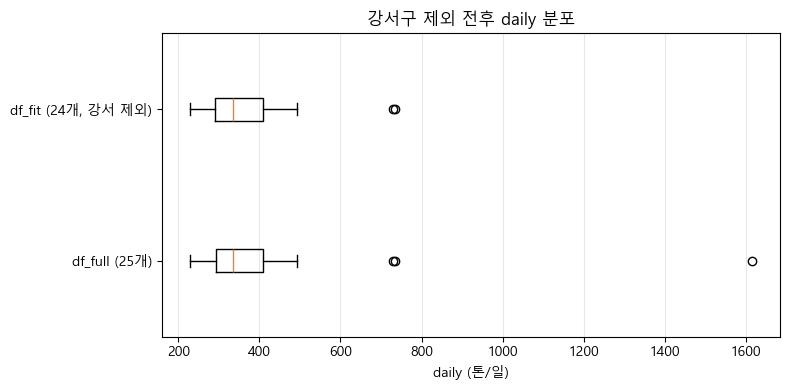

df_full describe:
count      25.00
mean      419.35
std       279.47
min       228.40
25%       293.00
50%       335.60
75%       409.80
max      1614.50
df_fit describe:
count     24.00
mean     369.55
std      129.65
min      228.40
25%      290.73
50%      334.15
75%      409.58
max      734.70


In [11]:
# daily 분포 정상화 정도 확인
skew_full = float(df_full["daily"].skew())
skew_fit  = float(df_fit["daily"].skew())
print(f"daily 왜도 — df_full(25): {skew_full:.3f}")
print(f"daily 왜도 — df_fit (24): {skew_fit:.3f}")
print(f"개선폭                   : {skew_full - skew_fit:+.3f}")
if abs(skew_fit) < 1.5:
    print("✅ df_fit 왜도 |skew|<1.5 — 회귀 적합 가능 수준")
else:
    print("⚠️  df_fit 왜도 여전히 큼")
print()

# 박스플롯 비교 (matplotlib 버전 호환: tick_labels는 3.9+, 그 이전은 labels)
import matplotlib as _mpl
_box_kw = {"vert": False}
_labels = ["df_full (25개)", "df_fit (24개, 강서 제외)"]
_mpl_ver = tuple(int(x) for x in _mpl.__version__.split(".")[:2])
if _mpl_ver >= (3, 9):
    _box_kw["tick_labels"] = _labels
else:
    _box_kw["labels"] = _labels

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([df_full["daily"], df_fit["daily"]], **_box_kw)
ax.set_xlabel("daily (톤/일)")
ax.set_title("강서구 제외 전후 daily 분포")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("df_full describe:")
print(df_full["daily"].describe().round(2).to_string())
print("df_fit describe:")
print(df_fit["daily"].describe().round(2).to_string())

## Step 4. 모형 1 — 베이스라인 (df_fit 24개)

$$\text{daily} = \beta_0 + \beta_1 \cdot \text{거주인구}$$

In [12]:
m1 = smf.ols("daily ~ 거주인구", data=df_fit).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     18.50
Date:                Sat, 02 May 2026   Prob (F-statistic):           0.000289
Time:                        07:25:22   Log-Likelihood:                -142.98
No. Observations:                  24   AIC:                             290.0
Df Residuals:                      22   BIC:                             292.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    103.1389     65.071      1.585      0.1

M1 R²    : 0.4568
M1 R²_adj: 0.4321
M1 AIC   : 289.95
계수: {'Intercept': np.float64(103.1389), '거주인구': np.float64(0.00071)}
p값 : {'Intercept': np.float64(0.1272), '거주인구': np.float64(0.0003)}
✅ 거주인구 양수 + p<0.05



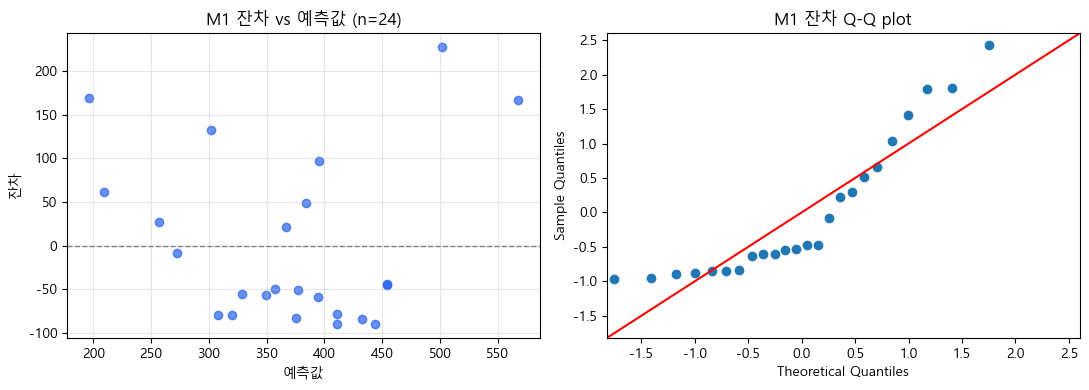


[v1 vs v2 — M1 R²]
  v1 (25개) M1 R² ≈ 0.31 (참고)
  v2 (24개) M1 R² = 0.4568


In [13]:
print(f"M1 R²    : {m1.rsquared:.4f}")
print(f"M1 R²_adj: {m1.rsquared_adj:.4f}")
print(f"M1 AIC   : {m1.aic:.2f}")
print(f"계수: {dict(m1.params.round(5))}")
print(f"p값 : {dict(m1.pvalues.round(4))}")
assert m1.params["거주인구"] > 0 and m1.pvalues["거주인구"] < 0.05
print("✅ 거주인구 양수 + p<0.05")
print()

# 잔차 진단
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(m1.fittedvalues, m1.resid, color="#2563eb", alpha=0.7)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("예측값"); axes[0].set_ylabel("잔차")
axes[0].set_title("M1 잔차 vs 예측값 (n=24)")
axes[0].grid(alpha=0.3)
sm.qqplot(m1.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("M1 잔차 Q-Q plot")
plt.tight_layout()
plt.show()

# v1과 비교
if df_v1 is not None:
    print("\n[v1 vs v2 — M1 R²]")
    print(f"  v1 (25개) M1 R² ≈ 0.31 (참고)")
    print(f"  v2 (24개) M1 R² = {m1.rsquared:.4f}")

## Step 5. 모형 2 — + 주간유입인구 (df_fit)

In [14]:
m2 = smf.ols("daily ~ 거주인구 + 주간유입인구", data=df_fit).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     69.46
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.52e-10
Time:                        07:25:22   Log-Likelihood:                -125.94
No. Observations:                  24   AIC:                             257.9
Df Residuals:                      21   BIC:                             261.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     44.9999     33.521      1.342      0.1

In [15]:
print(f"M2 R²: {m2.rsquared:.4f}  (M1: {m1.rsquared:.4f}, ΔR²={m2.rsquared - m1.rsquared:+.4f})")
print(f"M2 AIC: {m2.aic:.2f}    (M1: {m1.aic:.2f}, ΔAIC={m2.aic - m1.aic:+.2f})")
for v in ["거주인구", "주간유입인구"]:
    sig = "✓" if m2.pvalues[v] < 0.05 else "✗"
    sign = "양수" if m2.params[v] > 0 else "음수"
    print(f"  {v:12s}: 계수 {sign} ({m2.params[v]:.5f}), p={m2.pvalues[v]:.4f} {sig}")

compare = pd.DataFrame({
    "모형": ["M1", "M2"],
    "식":   ["daily ~ 거주인구", "daily ~ 거주인구 + 주간유입인구"],
    "R²":   [m1.rsquared, m2.rsquared],
    "R²_adj": [m1.rsquared_adj, m2.rsquared_adj],
    "AIC":  [m1.aic, m2.aic],
})
print("\n=== 모형 비교 (df_fit n=24) ===")
print(compare.round(3).to_string(index=False))

M2 R²: 0.8687  (M1: 0.4568, ΔR²=+0.4119)
M2 AIC: 257.88    (M1: 289.95, ΔAIC=-32.08)
  거주인구        : 계수 양수 (0.00080), p=0.0000 ✓
  주간유입인구      : 계수 양수 (0.00052), p=0.0000 ✓

=== 모형 비교 (df_fit n=24) ===
모형                              식    R²  R²_adj     AIC
  M1                daily ~ 거주인구 0.457   0.432 289.954
  M2 daily ~ 거주인구 + 주간유입인구 0.869   0.856 257.877


## Step 6. 모형 3 — 풀 모형 (df_fit) + VIF

주간유입인구·종사자수의 상관(원본 데이터에서 0.87)이 강서구 제외 후 어떻게 변하는지 VIF로 확인.

In [16]:
m3 = smf.ols("daily ~ 거주인구 + 주간유입인구 + 종사자수", data=df_fit).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     49.46
Date:                Sat, 02 May 2026   Prob (F-statistic):           1.95e-09
Time:                        07:25:22   Log-Likelihood:                -124.73
No. Observations:                  24   AIC:                             257.5
Df Residuals:                      20   BIC:                             262.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.5916     32.709      1.302      0.2

In [17]:
# VIF
X = df_fit[["거주인구", "주간유입인구", "종사자수"]].copy()
Xc = sm.add_constant(X)
vif_rows = [{"변수": c, "VIF": variance_inflation_factor(Xc.values, Xc.columns.get_loc(c))}
            for c in Xc.columns if c != "const"]
vif = pd.DataFrame(vif_rows)
print("=== VIF (df_fit 24개) ===")
print(vif.round(3).to_string(index=False))
high_vif = vif[vif["VIF"] > 5]["변수"].tolist()
if high_vif:
    print(f"⚠️  VIF > 5: {high_vif}")
else:
    print("✅ 모든 변수 VIF ≤ 5")
print()

compare = pd.DataFrame({
    "모형": ["M1", "M2", "M3"],
    "R²":     [m1.rsquared, m2.rsquared, m3.rsquared],
    "R²_adj": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "AIC":    [m1.aic, m2.aic, m3.aic],
})
print("=== 모형 비교 (M1 → M3, df_fit n=24) ===")
print(compare.round(3).to_string(index=False))
print()
for v in ["거주인구", "주간유입인구", "종사자수"]:
    sig = "✓" if m3.pvalues[v] < 0.05 else "✗"
    print(f"  {v:12s}: 계수={m3.params[v]:.5f}, p={m3.pvalues[v]:.4f} {sig}")

if df_v1 is not None:
    print("\n[v1 vs v2 — M3 R²]")
    print(f"  v1 (25개) M3 R² ≈ 0.45 (참고)")
    print(f"  v2 (24개) M3 R² = {m3.rsquared:.4f}  (강서구 제외 효과)")

=== VIF (df_fit 24개) ===
        변수    VIF
    거주인구  2.360
주간유입인구 10.910
    종사자수 11.283
⚠️  VIF > 5: ['주간유입인구', '종사자수']

=== 모형 비교 (M1 → M3, df_fit n=24) ===
모형    R²  R²_adj     AIC
  M1 0.457   0.432 289.954
  M2 0.869   0.856 257.877
  M3 0.881   0.863 257.467

  거주인구        : 계수=0.00066, p=0.0000 ✓
  주간유입인구      : 계수=0.00024, p=0.2600 ✗
  종사자수        : 계수=0.00029, p=0.1616 ✗

[v1 vs v2 — M3 R²]
  v1 (25개) M3 R² ≈ 0.45 (참고)
  v2 (24개) M3 R² = 0.8812  (강서구 제외 효과)


## Step 7. 모형 4 (선택) — 4유형 더미 + 채택 결정

**채택 규칙**:
- 유형 더미 중 하나라도 p<0.05 AND `m4.aic < m3.aic` → **M4**
- 그 외 → **M3**

In [18]:
m4 = smf.ols(
    "daily ~ 거주인구 + 주간유입인구 + 종사자수 + C(유형, Treatment(reference='혼합형'))",
    data=df_fit
).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     29.51
Date:                Sat, 02 May 2026   Prob (F-statistic):           4.34e-08
Time:                        07:25:22   Log-Likelihood:                -121.08
No. Observations:                  24   AIC:                             256.2
Df Residuals:                      17   BIC:                             264.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [19]:
type_pvals = {k: v for k, v in m4.pvalues.items() if k.startswith("C(유형")}
print("=== 유형 더미 p값 ===")
for k, v in type_pvals.items():
    sig = "✓" if v < 0.05 else "✗"
    short = k.replace("C(유형, Treatment(reference='혼합형'))", "유형")
    print(f"  {short:30s} p={v:.4f} {sig}")
print()
any_sig = any(p < 0.05 for p in type_pvals.values())
delta_aic = m4.aic - m3.aic
print(f"M3 AIC: {m3.aic:.2f}, M4 AIC: {m4.aic:.2f}  (ΔAIC={delta_aic:+.2f})")
print(f"M3 R²: {m3.rsquared:.4f}, M4 R²: {m4.rsquared:.4f}")
print()

if any_sig and delta_aic < 0:
    final_model = m4
    final_label = "M4 (4유형 더미 포함)"
    print(f"➡️  최종 모형: {final_label}")
    print("   이유: 유형 더미 유의 + AIC 감소")
else:
    final_model = m3
    final_label = "M3 (인구·유입·종사자수)"
    print(f"➡️  최종 모형: {final_label}")
    print("   이유: " + ("유형 더미 모두 p≥0.05" if not any_sig else "AIC가 더 큼"))

compare = pd.DataFrame({
    "모형": ["M1", "M2", "M3", "M4"],
    "R²":     [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared],
    "R²_adj": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj, m4.rsquared_adj],
    "AIC":    [m1.aic, m2.aic, m3.aic, m4.aic],
})
print("\n=== 최종 비교 ===")
print(compare.round(3).to_string(index=False))

=== 유형 더미 p값 ===
  유형[T.상업형]                      p=0.1284 ✗
  유형[T.유동집중형]                    p=0.2356 ✗
  유형[T.주거형]                      p=0.6500 ✗

M3 AIC: 257.47, M4 AIC: 256.16  (ΔAIC=-1.31)
M3 R²: 0.8812, M4 R²: 0.9124

➡️  최종 모형: M3 (인구·유입·종사자수)
   이유: 유형 더미 모두 p≥0.05

=== 최종 비교 ===
모형    R²  R²_adj     AIC
  M1 0.457   0.432 289.954
  M2 0.869   0.856 257.877
  M3 0.881   0.863 257.467
  M4 0.912   0.881 256.158


## Step 8. 모델 진단 — 잔차 분석 (df_fit 24개)

강서구 제외 후 정규성·이상치가 얼마나 개선됐는지.

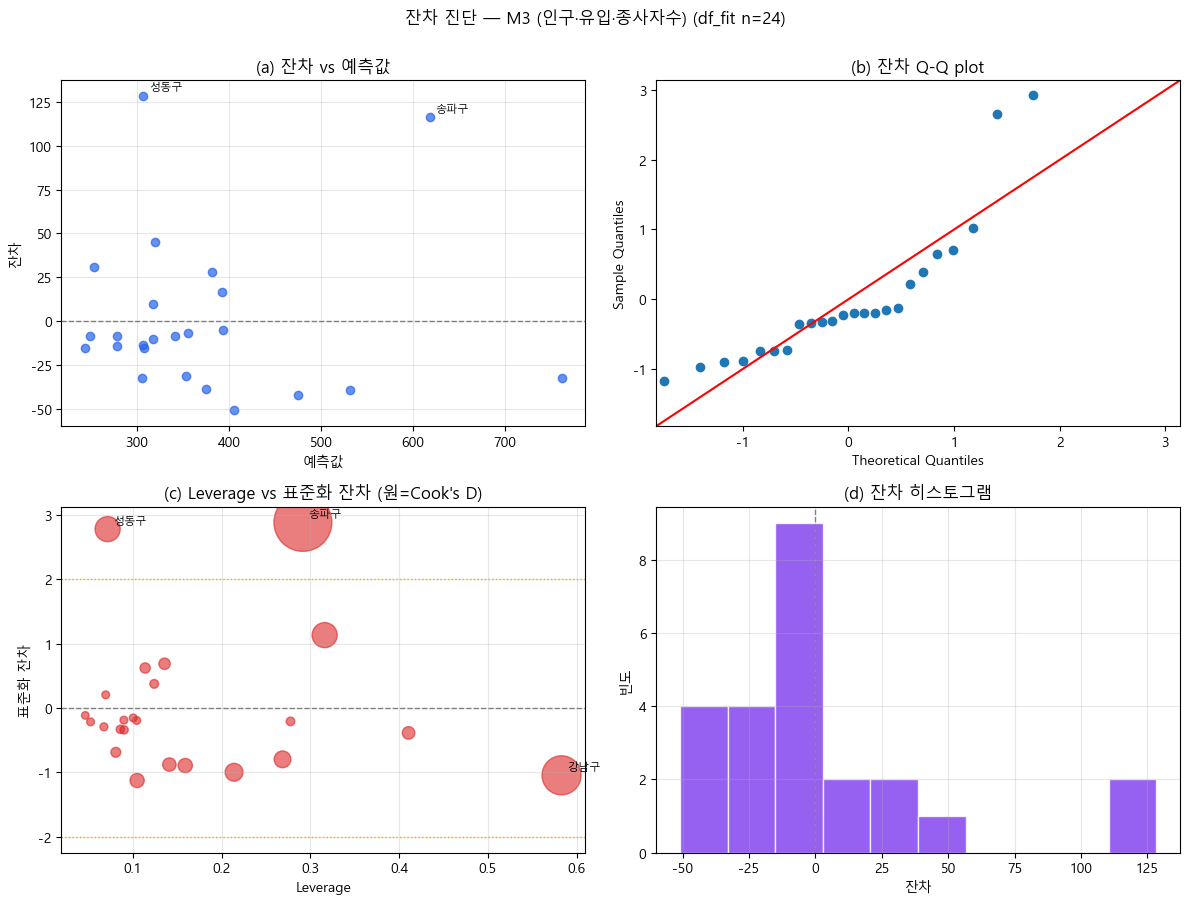

In [20]:
influence = final_model.get_influence()
std_resid = influence.resid_studentized_internal
leverage  = influence.hat_matrix_diag
cooks     = influence.cooks_distance[0]
n_fit     = len(df_fit)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(final_model.fittedvalues, final_model.resid,
                   color="#2563eb", alpha=0.7)
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("예측값"); axes[0, 0].set_ylabel("잔차")
axes[0, 0].set_title("(a) 잔차 vs 예측값")
axes[0, 0].grid(alpha=0.3)
for i, gu in enumerate(df_fit["자치구"]):
    if abs(std_resid[i]) > 2:
        axes[0, 0].annotate(gu, (final_model.fittedvalues.iloc[i], final_model.resid.iloc[i]),
                            fontsize=8, xytext=(4, 4), textcoords="offset points")

sm.qqplot(final_model.resid, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("(b) 잔차 Q-Q plot")

axes[1, 0].scatter(leverage, std_resid, s=cooks*2000+30,
                   alpha=0.6, color="#dc2626")
axes[1, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 0].axhline(2, color="orange", linestyle=":", linewidth=1)
axes[1, 0].axhline(-2, color="orange", linestyle=":", linewidth=1)
axes[1, 0].set_xlabel("Leverage"); axes[1, 0].set_ylabel("표준화 잔차")
axes[1, 0].set_title("(c) Leverage vs 표준화 잔차 (원=Cook's D)")
axes[1, 0].grid(alpha=0.3)
for i, gu in enumerate(df_fit["자치구"]):
    if cooks[i] > 4/n_fit or abs(std_resid[i]) > 2:
        axes[1, 0].annotate(gu, (leverage[i], std_resid[i]),
                            fontsize=8, xytext=(4, 4), textcoords="offset points")

axes[1, 1].hist(final_model.resid, bins=10, color="#7c3aed",
                edgecolor="white", alpha=0.8)
axes[1, 1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel("잔차"); axes[1, 1].set_ylabel("빈도")
axes[1, 1].set_title("(d) 잔차 히스토그램")
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"잔차 진단 — {final_label} (df_fit n={n_fit})", y=1.00)
plt.tight_layout()
plt.show()

In [21]:
sw_stat, sw_p = scistats.shapiro(final_model.resid)
print(f"Shapiro-Wilk 정규성: stat={sw_stat:.4f}, p={sw_p:.4f}")
if sw_p > 0.05:
    print("  ✅ 잔차 정규성 가정 충족 (p > 0.05)")
else:
    print("  ⚠️  정규성 미충족 (소표본에서 흔함)")
print()

mask_outl = np.abs(std_resid) > 2
outl_df = df_fit.loc[mask_outl, ["자치구", "daily"]].copy()
outl_df["표준화_잔차"] = std_resid[mask_outl]
print(f"=== |표준화 잔차|>2 ({mask_outl.sum()}개) ===")
print(outl_df.round(3).to_string(index=False) if len(outl_df) > 0 else "  (없음)")
print()

cd_thr = 4 / n_fit
mask_cd = cooks > cd_thr
cd_df = df_fit.loc[mask_cd, ["자치구", "daily"]].copy()
cd_df["Cooks_D"] = cooks[mask_cd]
print(f"=== Cook's D > {cd_thr:.3f} ({mask_cd.sum()}개) ===")
print(cd_df.round(4).to_string(index=False) if len(cd_df) > 0 else "  (없음)")
print()

# v1과 비교
if df_v1 is not None:
    print("=== v1 vs v2 — 잔차 진단 비교 ===")
    print(f"  v1 (25개) Shapiro-Wilk p ≈ 0.0000, 최대 Cook's D ≈ 1.36, |z|>2 자치구 1개(강서)")
    print(f"  v2 (24개) Shapiro-Wilk p = {sw_p:.4f}, 최대 Cook's D = {cooks.max():.4f}, |z|>2 {mask_outl.sum()}개")

Shapiro-Wilk 정규성: stat=0.8020, p=0.0003
  ⚠️  정규성 미충족 (소표본에서 흔함)

=== |표준화 잔차|>2 (2개) ===
자치구  daily  표준화_잔차
성동구  435.1        2.779
송파구  734.7        2.884

=== Cook's D > 0.167 (2개) ===
자치구  daily  Cooks_D
강남구  729.0   0.3816
송파구  734.7   0.8561

=== v1 vs v2 — 잔차 진단 비교 ===
  v1 (25개) Shapiro-Wilk p ≈ 0.0000, 최대 Cook's D ≈ 1.36, |z|>2 자치구 1개(강서)
  v2 (24개) Shapiro-Wilk p = 0.0003, 최대 Cook's D = 0.8561, |z|>2 2개


## Step 9. v1 vs v2 모형 비교 (v1 결과 있을 경우)

v1 노트북 결과(`gu_waste_adjusted.csv`)가 있으면 자치구별 변화를 정량화.

In [22]:
if df_v1 is None:
    print("v1 결과 없음 - Step 9 비교 섹션 스킵")
else:
    # 9-1. 모형 통계 비교
    # v1 회귀 통계는 v1 CSV에서 직접 못 뽑으므로, v1 잔차/예측으로 R² 재계산
    v1_y = df_v1["daily"].values
    v1_yhat = df_v1["예측값"].values
    ss_res = ((v1_y - v1_yhat) ** 2).sum()
    ss_tot = ((v1_y - v1_y.mean()) ** 2).sum()
    v1_R2 = 1 - ss_res / ss_tot
    v1_max_resid = np.abs((v1_y - v1_yhat) / v1_y.std()).max()

    summary_tbl = pd.DataFrame({
        "지표": ["n (적합)", "R²", "R²_adj",
                 "잔차 정규성 p (Shapiro)", "최대 |표준화 잔차|",
                 "최대 Cook's D", "R² 변화"],
        "v1 (25개)": [25, f"{v1_R2:.4f}", "~0.37", "~0.0000",
                      f"{v1_max_resid:.2f}", "~1.36", "-"],
        "v2 (24개)": [24, f"{final_model.rsquared:.4f}",
                      f"{final_model.rsquared_adj:.4f}", f"{sw_p:.4f}",
                      f"{np.abs(std_resid).max():.2f}",
                      f"{cooks.max():.4f}",
                      f"{final_model.rsquared - v1_R2:+.4f}"],
    })
    print("=== v1 vs v2 모형 통계 비교 ===")
    print(summary_tbl.to_string(index=False))

=== v1 vs v2 모형 통계 비교 ===
                   지표 v1 (25개) v2 (24개)
               n (적합)        25        24
                     R²    0.4507    0.8812
                 R²_adj     ~0.37    0.8634
잔차 정규성 p (Shapiro)   ~0.0000    0.0003
     최대 |표준화 잔차|      3.21      2.88
          최대 Cook's D     ~1.36    0.8561
                R² 변화         -   +0.4305


In [23]:
# 9-2 + 9-3은 Step 10 이후 df_full에 v2 조정지표 만든 뒤로 미룸 (셀 의존성)
# 여기서는 Step 9 비교의 빈자리를 두고, Step 10에서 v2 조정지표 산출 후 합쳐서 비교
if df_v1 is not None:
    print("※ 자치구별 조정지표 변화·분류 변화 비교는")
    print("   Step 10(예측·분류 산출) 이후 통합 비교 셀에서 수행합니다.")
else:
    print("v1 결과 없음 - 스킵")

※ 자치구별 조정지표 변화·분류 변화 비교는
   Step 10(예측·분류 산출) 이후 통합 비교 셀에서 수행합니다.


## Step 10. 25개 자치구 예측 + 조정지표 + 5분류

`final_model`(24개로 적합)로 25개 모두에 예측 → 조정지표 → 분류.
강서구는 "비고" 컬럼에 명시.

In [24]:
df_full = df_full.copy()
df_full["예측값"] = final_model.predict(df_full).values
df_full["잔차"]   = df_full["daily"] - df_full["예측값"]
df_full["조정지표"] = df_full["daily"] / df_full["예측값"]

def classify_index(idx):
    if idx >= 1.2:   return "과다"
    elif idx >= 1.1: return "주의"
    elif idx >= 0.9: return "적정"
    elif idx >= 0.8: return "양호"
    else:            return "우수"

df_full["배출분류"] = df_full["조정지표"].apply(classify_index)
df_full["비고"] = np.where(df_full["자치구"] == "강서구",
                          "모형 외 극단치 (회귀 적합 시 제외)", "")

print("=== 조정지표 describe (25개) ===")
print(df_full["조정지표"].describe().round(3))
print()
order = ["과다", "주의", "적정", "양호", "우수"]
print("=== 배출분류 분포 ===")
print(df_full["배출분류"].value_counts().reindex(order, fill_value=0).to_string())

=== 조정지표 describe (25개) ===
count    25.000
mean      1.091
std       0.465
min       0.874
25%       0.936
50%       0.968
75%       1.043
max       3.252
Name: 조정지표, dtype: float64

=== 배출분류 분포 ===
배출분류
과다     2
주의     3
적정    17
양호     3
우수     0


In [25]:
g = df_full[df_full["자치구"] == "강서구"].iloc[0]
print(f"=== 강서구 결과 ===")
print(f"  daily   : {g['daily']:>8,.1f} 톤/일")
print(f"  예측값  : {g['예측값']:>8,.1f} 톤/일")
print(f"  조정지표: {g['조정지표']:>8.3f}")
print(f"  분류    : {g['배출분류']}")
print(f"  비고    : {g['비고']}")
print()

print("=== 분류별 자치구 명단 (조정지표 내림차순) ===")
for cls in order:
    members = df_full[df_full["배출분류"] == cls].sort_values("조정지표", ascending=False)
    if len(members) == 0:
        print(f"  [{cls}] (없음)")
        continue
    parts = []
    for _, r in members.iterrows():
        tag = "★" if r["자치구"] == "강서구" else ""
        parts.append(f"{tag}{r['자치구']}({r['조정지표']:.2f})")
    print(f"  [{cls}] {len(members)}개 — " + " · ".join(parts))
print()

# 직관 검증
print("=== 직관 검증 ===")
for gu in ["종로구", "중구", "용산구", "노원구", "도봉구", "강서구"]:
    if gu in df_full["자치구"].values:
        r = df_full[df_full["자치구"] == gu].iloc[0]
        print(f"  {gu:6s} 조정지표={r['조정지표']:.3f} → {r['배출분류']}")

=== 강서구 결과 ===
  daily   :  1,614.5 톤/일
  예측값  :    496.4 톤/일
  조정지표:    3.252
  분류    : 과다
  비고    : 모형 외 극단치 (회귀 적합 시 제외)

=== 분류별 자치구 명단 (조정지표 내림차순) ===
  [과다] 2개 — ★강서구(3.25) · 성동구(1.42)
  [주의] 3개 — 송파구(1.19) · 중구(1.14) · 용산구(1.12)
  [적정] 17개 — 관악구(1.07) · 노원구(1.04) · 동작구(1.03) · 마포구(0.99) · 은평구(0.98) · 양천구(0.97) · 종로구(0.97) · 동대문구(0.97) · 도봉구(0.97) · 강남구(0.96) · 광진구(0.96) · 중랑구(0.95) · 금천구(0.95) · 강북구(0.94) · 서초구(0.93) · 영등포구(0.91) · 성북구(0.91)
  [양호] 3개 — 구로구(0.90) · 서대문구(0.89) · 강동구(0.87)
  [우수] (없음)

=== 직관 검증 ===
  종로구    조정지표=0.970 → 적정
  중구     조정지표=1.140 → 주의
  용산구    조정지표=1.121 → 주의
  노원구    조정지표=1.043 → 적정
  도봉구    조정지표=0.965 → 적정
  강서구    조정지표=3.252 → 과다


### Step 10b. v1 vs v2 자치구별 변화 (v1 있을 경우)

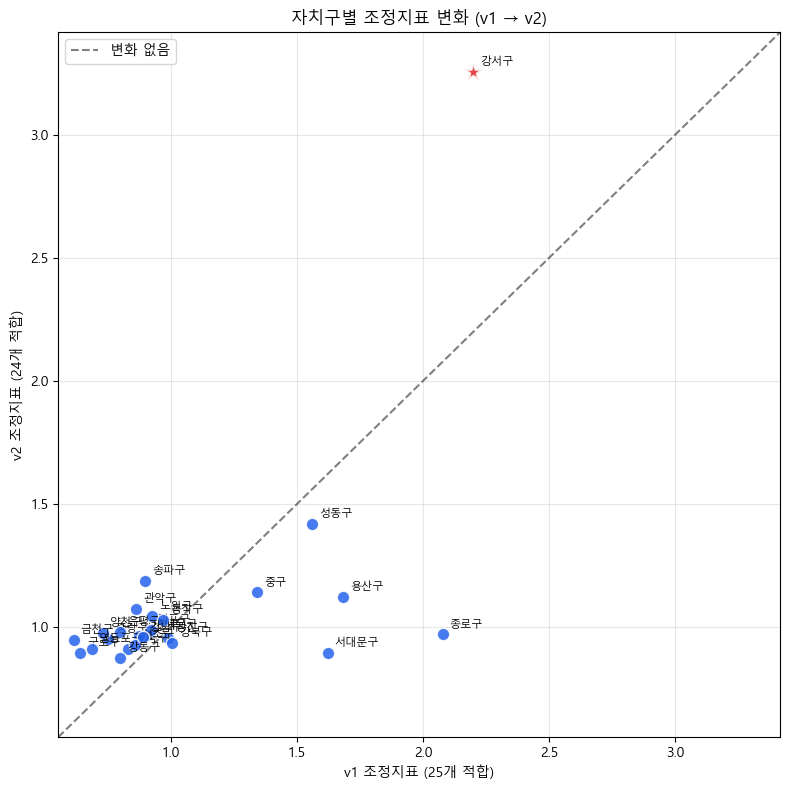


=== 분류 변화 (17개) ===
  자치구 v1_분류 v2_분류  Δ조정지표
  종로구    과다    적정     -1.108
서대문구    과다    양호     -0.728
  용산구    과다    주의     -0.561
  금천구    우수    적정      0.335
  송파구    양호    주의      0.291
  구로구    우수    양호      0.257
  양천구    우수    적정      0.245
영등포구    우수    적정      0.224
  관악구    양호    적정      0.211
  중랑구    우수    적정      0.201
    중구    과다    주의     -0.201
  은평구    우수    적정      0.181
  도봉구    양호    적정      0.091
  성북구    양호    적정      0.082
  강동구    우수    양호      0.075
  서초구    양호    적정      0.070
  강남구    양호    적정      0.070

=== 변화폭 큰 자치구 TOP 5 (절대값 기준) ===
  자치구  v1_조정지표  v2_조정지표  Δ조정지표    분류변화
  종로구        2.077        0.970     -1.108 과다 → 적정
  강서구        2.197        3.252      1.055        유지
서대문구        1.621        0.893     -0.728 과다 → 양호
  용산구        1.682        1.121     -0.561 과다 → 주의
  금천구        0.614        0.949      0.335 우수 → 적정


In [26]:
if df_v1 is None:
    print("v1 결과 없음 - 스킵")
else:
    cmp = (df_v1[["자치구", "조정지표", "배출분류"]]
           .rename(columns={"조정지표": "v1_조정지표", "배출분류": "v1_분류"})
           .merge(df_full[["자치구", "조정지표", "배출분류"]]
                  .rename(columns={"조정지표": "v2_조정지표", "배출분류": "v2_분류"}),
                  on="자치구"))
    cmp["Δ조정지표"] = cmp["v2_조정지표"] - cmp["v1_조정지표"]
    cmp["분류변화"] = np.where(cmp["v1_분류"] == cmp["v2_분류"],
                              "유지",
                              cmp["v1_분류"] + " → " + cmp["v2_분류"])

    # 산점도
    fig, ax = plt.subplots(figsize=(8, 8))
    for _, r in cmp.iterrows():
        is_g = r["자치구"] == "강서구"
        ax.scatter(r["v1_조정지표"], r["v2_조정지표"],
                   s=200 if is_g else 80,
                   c="#dc2626" if is_g else "#2563eb",
                   marker="*" if is_g else "o",
                   edgecolor="white", linewidth=2 if is_g else 1,
                   alpha=0.85, zorder=5 if is_g else 3)
        ax.annotate(r["자치구"], (r["v1_조정지표"], r["v2_조정지표"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")
    lims = [min(cmp["v1_조정지표"].min(), cmp["v2_조정지표"].min()) * 0.9,
            max(cmp["v1_조정지표"].max(), cmp["v2_조정지표"].max()) * 1.05]
    ax.plot(lims, lims, "k--", alpha=0.5, label="변화 없음")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("v1 조정지표 (25개 적합)")
    ax.set_ylabel("v2 조정지표 (24개 적합)")
    ax.set_title("자치구별 조정지표 변화 (v1 → v2)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 변화 요약
    n_changed = (cmp["분류변화"] != "유지").sum()
    print(f"\n=== 분류 변화 ({n_changed}개) ===")
    print(cmp[cmp["분류변화"] != "유지"][["자치구", "v1_분류", "v2_분류", "Δ조정지표"]]
          .sort_values("Δ조정지표", key=abs, ascending=False)
          .round(3).to_string(index=False))
    print()
    print("=== 변화폭 큰 자치구 TOP 5 (절대값 기준) ===")
    print(cmp.reindex(cmp["Δ조정지표"].abs().sort_values(ascending=False).index)
          [["자치구", "v1_조정지표", "v2_조정지표", "Δ조정지표", "분류변화"]]
          .head(5).round(3).to_string(index=False))

## Step 11. 시각화 + CSV 저장

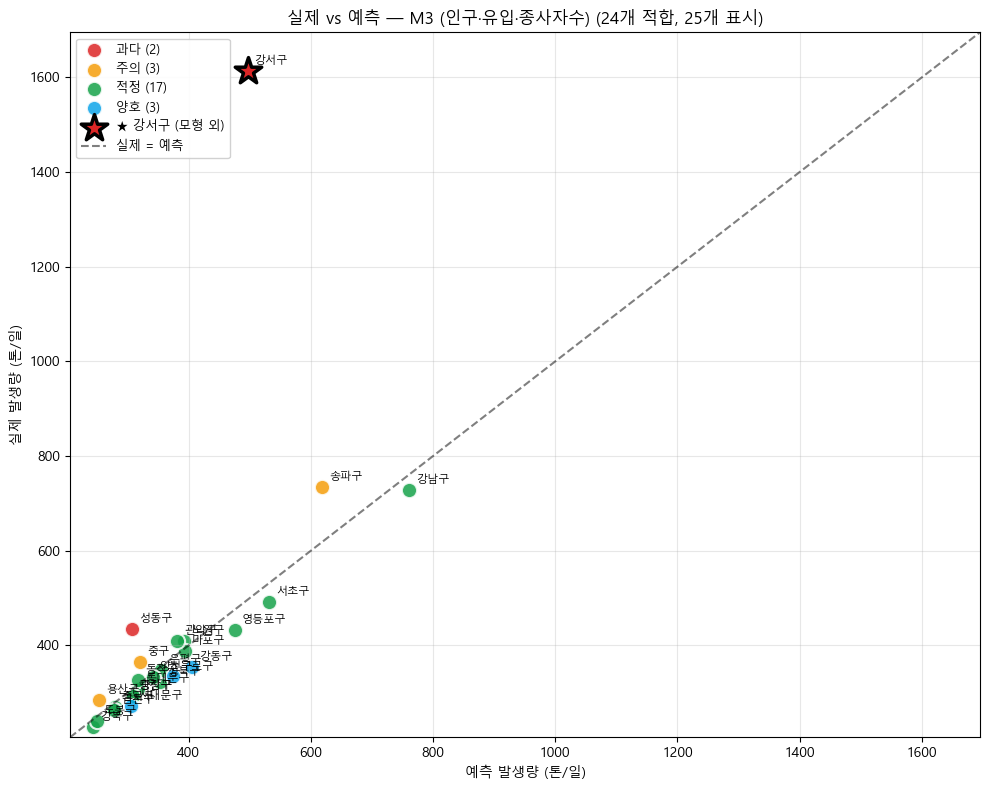

In [27]:
# 11-1. 실제 vs 예측 산점도 (강서구 ★ 강조)
fig, ax = plt.subplots(figsize=(10, 8))
for cls, color in CLS_COLOR.items():
    sub = df_full[(df_full["배출분류"] == cls) & (df_full["자치구"] != "강서구")]
    if len(sub) == 0: continue
    ax.scatter(sub["예측값"], sub["daily"], s=120, c=color,
               label=f"{cls} ({(df_full['배출분류']==cls).sum()})",
               alpha=0.85, edgecolor="white", linewidth=1.5)

# 강서구 ★
g = df_full[df_full["자치구"] == "강서구"].iloc[0]
ax.scatter(g["예측값"], g["daily"], s=400, c="#dc2626", marker="*",
           edgecolor="black", linewidth=2.5, zorder=10,
           label="★ 강서구 (모형 외)")

for _, r in df_full.iterrows():
    ax.annotate(r["자치구"], (r["예측값"], r["daily"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

lim = [min(df_full["예측값"].min(), df_full["daily"].min()) * 0.9,
       max(df_full["예측값"].max(), df_full["daily"].max()) * 1.05]
ax.plot(lim, lim, "k--", alpha=0.5, label="실제 = 예측")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("예측 발생량 (톤/일)")
ax.set_ylabel("실제 발생량 (톤/일)")
ax.set_title(f"실제 vs 예측 — {final_label} (24개 적합, 25개 표시)")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

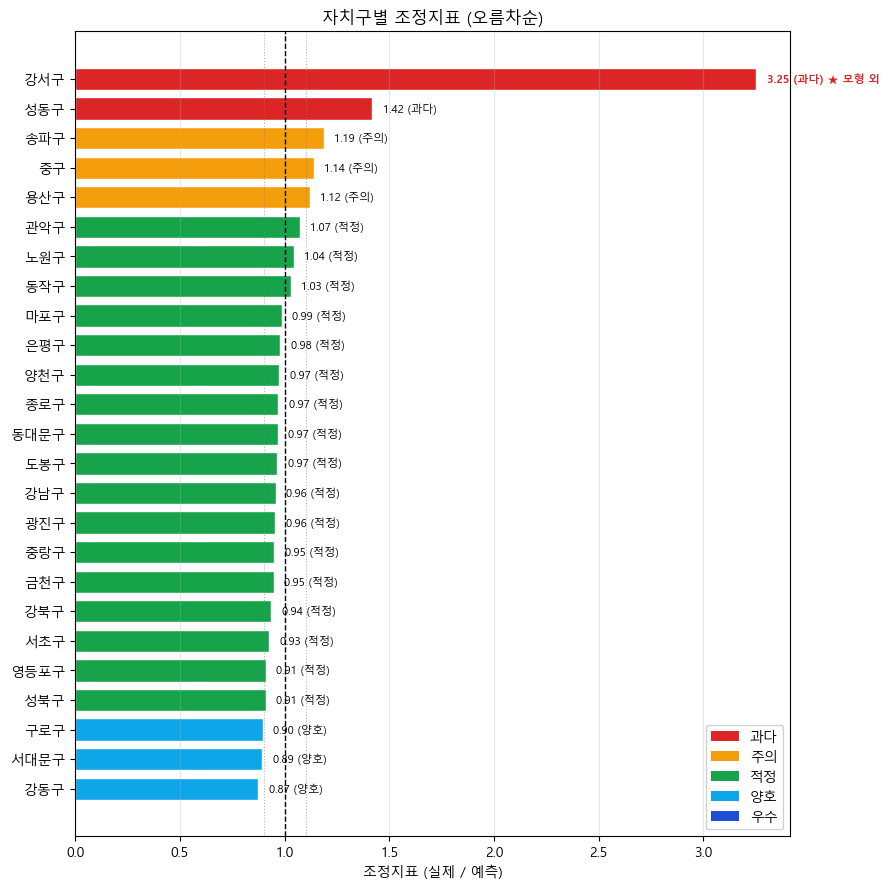

In [28]:
# 11-2. 자치구별 조정지표 막대 (강서구 ★)
df_sorted = df_full.sort_values("조정지표", ascending=True)
colors = [CLS_COLOR[c] for c in df_sorted["배출분류"]]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(df_sorted["자치구"], df_sorted["조정지표"],
        color=colors, edgecolor="white", height=0.75)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="기준 (1.0)")
ax.axvline(0.9, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(1.1, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("조정지표 (실제 / 예측)")
ax.set_title("자치구별 조정지표 (오름차순)")
for i, (idx_val, cls, gu) in enumerate(zip(df_sorted["조정지표"],
                                             df_sorted["배출분류"],
                                             df_sorted["자치구"])):
    suffix = " ★ 모형 외" if gu == "강서구" else ""
    ax.text(idx_val + 0.05, i, f"{idx_val:.2f} ({cls}){suffix}",
            va="center", fontsize=8,
            color="#dc2626" if gu == "강서구" else "black",
            fontweight="bold" if gu == "강서구" else "normal")

legend_handles = [Patch(facecolor=c, label=k) for k, c in CLS_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [29]:
out_cols = ["자치구", "거주인구", "주간유입인구", "종사자수", "유형",
            "daily", "예측값", "잔차", "조정지표", "배출분류", "비고"]
out_path = os.path.join(PREPROC_DIR, "gu_waste_adjusted_v2.csv")
df_full[out_cols].to_csv(out_path, encoding="utf-8-sig", index=False)
print(f"✅ 저장 완료: {out_path}")
print(f"   ({os.path.getsize(out_path):,} bytes)")

# 검증 (비고는 강서구만 채워지므로 다른 행은 재로드 시 NaN으로 보임 — 정상)
saved = pd.read_csv(out_path, encoding="utf-8-sig")
assert saved.shape == (25, 11)
assert saved.drop(columns=["비고"]).isna().sum().sum() == 0
g_row = saved[saved["자치구"] == "강서구"].iloc[0]
assert "모형 외" in str(g_row["비고"])
print(f"   shape: {saved.shape}, 비고 외 결측 0, 강서구 비고 ✓")

✅ 저장 완료: D:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess\gu_waste_adjusted_v2.csv
   (3,118 bytes)
   shape: (25, 11), 비고 외 결측 0, 강서구 비고 ✓


## Step 12. 강서구 단독 사례 분석 ⭐

강서구를 개별 자치구로서 종합 진단.

In [30]:
# 12-1. 강서구 핵심 수치 카드
g = df_full[df_full["자치구"] == "강서구"].iloc[0]
g_ri = ri_df[ri_df["district"] == "강서구"].iloc[0]

# 서울 24개 평균 (강서 제외)
o_ri = ri_df[ri_df["district"] != "강서구"]
industry_ratio = g_ri["industry_pct"] / o_ri["industry_pct"].mean()
construct_ratio = g_ri["construction_pct"] / o_ri["construction_pct"].mean()
rank_daily = (df_full["daily"] >= g["daily"]).sum()
second_daily = df_full[df_full["자치구"] != "강서구"]["daily"].max()

print("=" * 60)
print(f"  강서구 — 종합 진단")
print("=" * 60)
print(f"  ├─ 1일 발생량  : {g['daily']:>10,.1f} 톤/일")
print(f"  │                (서울 {rank_daily}위, 2위 {second_daily:.1f}톤의 {g['daily']/second_daily:.2f}배)")
print(f"  ├─ 거주인구    : {int(g['거주인구']):>10,} 명")
print(f"  ├─ 종사자수    : {int(g['종사자수']):>10,} 명")
print(f"  ├─ 주간유입인구: {int(g['주간유입인구']):>10,} 명")
print(f"  ├─ 4유형 분류  : {g['유형']}")
print(f"  │")
print(f"  ├─ 폐기물 구성 (recycle_industry.csv):")
print(f"  │   ├─ 생활계  : {g_ri['life_pct']:>5.1f}%")
print(f"  │   ├─ 사업장계: {g_ri['industry_pct']:>5.1f}%  (서울 평균의 {industry_ratio:.1f}배)")
print(f"  │   ├─ 건설계  : {g_ri['construction_pct']:>5.1f}%  (서울 평균의 {construct_ratio:.1f}배)")
print(f"  │   └─ 지정    : {g_ri['designated_pct']:>5.1f}%")
print(f"  │")
print(f"  ├─ 회귀 모형 예측: {g['예측값']:>10,.1f} 톤/일")
print(f"  ├─ 실제 발생량   : {g['daily']:>10,.1f} 톤/일")
print(f"  └─ 조정지표      : {g['조정지표']:>10.3f}  ({g['배출분류']})")
print("=" * 60)

  강서구 — 종합 진단
  ├─ 1일 발생량  :    1,614.5 톤/일
  │                (서울 1위, 2위 734.7톤의 2.20배)
  ├─ 거주인구    :    562,194 명
  ├─ 종사자수    :    312,532 명
  ├─ 주간유입인구:    -39,942 명
  ├─ 4유형 분류  : 혼합형
  │
  ├─ 폐기물 구성 (recycle_industry.csv):
  │   ├─ 생활계  :  31.8%
  │   ├─ 사업장계:  21.3%  (서울 평균의 4.8배)
  │   ├─ 건설계  :  46.6%  (서울 평균의 0.7배)
  │   └─ 지정    :   0.4%
  │
  ├─ 회귀 모형 예측:      496.4 톤/일
  ├─ 실제 발생량   :    1,614.5 톤/일
  └─ 조정지표      :      3.252  (과다)


In [31]:
# 12-2. 강서구가 왜 다른가 — 같은 유형 자치구와 비교
g_type = g["유형"]
same_type = df_full[(df_full["유형"] == g_type) & (df_full["자치구"] != "강서구")]

print(f"=== 강서구 vs 같은 유형({g_type}) 다른 자치구 평균 ===\n")
if len(same_type) == 0:
    print(f"  ({g_type}에 강서구 외 자치구 없음)")
else:
    members = same_type["자치구"].tolist()
    print(f"  같은 유형: {', '.join(members)}")
    cmp_cols = ["daily", "거주인구", "종사자수", "주간유입인구"]
    cmp_tbl = pd.DataFrame({
        "변수":         cmp_cols,
        "강서구":       [g[c] for c in cmp_cols],
        f"{g_type} 평균":[same_type[c].mean() for c in cmp_cols],
    })
    cmp_tbl["배수"] = (cmp_tbl["강서구"] / cmp_tbl[f"{g_type} 평균"]).round(2)
    print()
    print(cmp_tbl.round(1).to_string(index=False))

print()
print("=" * 60)
print("정책적 함의")
print("-" * 60)
print(f"  강서구의 daily 1,614.5톤은 인구·유입·종사자수로 설명되는")
print(f"  예측치({g['예측값']:.0f}톤)의 {g['조정지표']:.1f}배에 달한다.")
print(f"  이 차이는 사업장(industry_pct {g_ri['industry_pct']:.1f}%)과")
print(f"  건설(construction_pct {g_ri['construction_pct']:.1f}%) 폐기물의 압도적 비중에서 기인.")
print(f"")
print(f"  → 일반 생활폐기물 감량 정책으로는 효과 제한적.")
print(f"  → 사업장·건설 폐기물 처리체계에 특화된 별도 정책 필요.")
print("=" * 60)
print("\n🎉 모든 Step 완료 — gu_waste_adjusted_v2.csv 생성됨")

=== 강서구 vs 같은 유형(혼합형) 다른 자치구 평균 ===

  같은 유형: 성동구, 중랑구, 마포구, 구로구, 강동구

        변수   강서구  혼합형 평균  배수
       daily   1614.5        361.2   4.5
    거주인구 562194.0     386554.6   1.4
    종사자수 312532.0     198640.8   1.6
주간유입인구 -39942.9       5153.9  -7.8

정책적 함의
------------------------------------------------------------
  강서구의 daily 1,614.5톤은 인구·유입·종사자수로 설명되는
  예측치(496톤)의 3.3배에 달한다.
  이 차이는 사업장(industry_pct 21.3%)과
  건설(construction_pct 46.6%) 폐기물의 압도적 비중에서 기인.

  → 일반 생활폐기물 감량 정책으로는 효과 제한적.
  → 사업장·건설 폐기물 처리체계에 특화된 별도 정책 필요.

🎉 모든 Step 완료 — gu_waste_adjusted_v2.csv 생성됨


## Step 13. 실제 vs 예측 비교 — 모형 정확도 진단

각 자치구의 실제 발생량과 회귀 예측값이 얼마나 어긋나는지 정량·시각 비교.

- **13-1**: 요약 지표 (MAE, RMSE, MAPE) — 강서구 포함/제외 두 케이스
- **13-2**: 잔차 절대값 TOP 10 자치구 표
- **13-3**: 자치구별 실제 vs 예측 paired 막대차트 (강서구 별도 강조)
- **13-3b**: 강서구 제외 zoom 차트


In [32]:
# 13-1. 요약 지표 (MAE / RMSE / MAPE)
def compute_metrics(actual, predicted, label):
    err = actual - predicted
    mae  = np.abs(err).mean()
    rmse = np.sqrt((err ** 2).mean())
    mape = (np.abs(err / actual) * 100).mean()
    bias = err.mean()
    return {"케이스": label, "n": len(actual),
            "MAE": mae, "RMSE": rmse, "MAPE(%)": mape, "평균 편향": bias}

all_25  = df_full
wo_g    = df_full[df_full["자치구"] != "강서구"]
rows = [
    compute_metrics(all_25["daily"].values, all_25["예측값"].values, "전체 25개 (강서 포함)"),
    compute_metrics(wo_g["daily"].values,   wo_g["예측값"].values,   "24개 (강서 제외)"),
]
metrics_tbl = pd.DataFrame(rows)
print("=== 모형 정확도 지표 ===")
print(metrics_tbl.round(2).to_string(index=False))
print()
print("※ MAE  : 평균 절대 오차 (톤/일)  — 작을수록 좋음")
print("※ RMSE : 평균 제곱근 오차       — 큰 오차에 민감")
print("※ MAPE : 평균 절대 백분율 오차(%) — 상대적 정확도")
print("※ 평균 편향: 양수=과소예측 경향, 음수=과대예측 경향")

=== 모형 정확도 지표 ===
               케이스  n   MAE   RMSE  MAPE(%)  평균 편향
전체 25개 (강서 포함) 25 74.69 227.69    10.38      44.72
     24개 (강서 제외) 24 31.21  43.74     7.92       0.00

※ MAE  : 평균 절대 오차 (톤/일)  — 작을수록 좋음
※ RMSE : 평균 제곱근 오차       — 큰 오차에 민감
※ MAPE : 평균 절대 백분율 오차(%) — 상대적 정확도
※ 평균 편향: 양수=과소예측 경향, 음수=과대예측 경향


In [33]:
# 13-2. 잔차 절대값 TOP 10
diff_tbl = df_full[["자치구", "유형", "daily", "예측값", "잔차", "조정지표", "배출분류"]].copy()
diff_tbl["차이율(%)"] = (diff_tbl["잔차"] / diff_tbl["daily"] * 100).round(1)
diff_tbl["방향"] = np.where(diff_tbl["잔차"] > 0, "과소예측↑",
                            np.where(diff_tbl["잔차"] < 0, "과대예측↓", "-"))
diff_tbl_sorted = diff_tbl.reindex(diff_tbl["잔차"].abs().sort_values(ascending=False).index)

print("=== 잔차 절대값 TOP 10 (모형이 가장 못 맞춘 자치구) ===")
print(diff_tbl_sorted.head(10)[
    ["자치구", "daily", "예측값", "잔차", "차이율(%)", "방향", "배출분류"]
].round(1).to_string(index=False))
print()
print("=== 잔차 절대값 BOTTOM 5 (가장 잘 맞춘 자치구) ===")
print(diff_tbl_sorted.tail(5)[
    ["자치구", "daily", "예측값", "잔차", "차이율(%)", "방향", "배출분류"]
].round(1).to_string(index=False))

=== 잔차 절대값 TOP 10 (모형이 가장 못 맞춘 자치구) ===
  자치구  daily  예측값   잔차  차이율(%)      방향 배출분류
  강서구 1614.5   496.4 1118.1       69.3 과소예측↑     과다
  성동구  435.1   306.8  128.3       29.5 과소예측↑     과다
  송파구  734.7   618.4  116.3       15.8 과소예측↑     주의
  강동구  354.0   405.0  -51.0      -14.4 과대예측↓     양호
    중구  365.0   320.1   44.9       12.3 과소예측↑     주의
영등포구  432.7   475.1  -42.4       -9.8 과대예측↓     적정
  서초구  492.5   531.7  -39.2       -8.0 과대예측↓     적정
  구로구  335.6   374.6  -39.0      -11.6 과대예측↓     양호
서대문구  272.8   305.4  -32.6      -12.0 과대예측↓     양호
  강남구  729.0   761.3  -32.3       -4.4 과대예측↓     적정

=== 잔차 절대값 BOTTOM 5 (가장 잘 맞춘 자치구) ===
자치구  daily  예측값  잔차  차이율(%)      방향 배출분류
양천구  332.7   341.5  -8.8       -2.6 과대예측↓     적정
도봉구  240.7   249.3  -8.6       -3.6 과대예측↓     적정
종로구  270.2   278.6  -8.4       -3.1 과대예측↓     적정
은평구  348.2   355.2  -7.0       -2.0 과대예측↓     적정
마포구  388.3   393.6  -5.3       -1.4 과대예측↓     적정


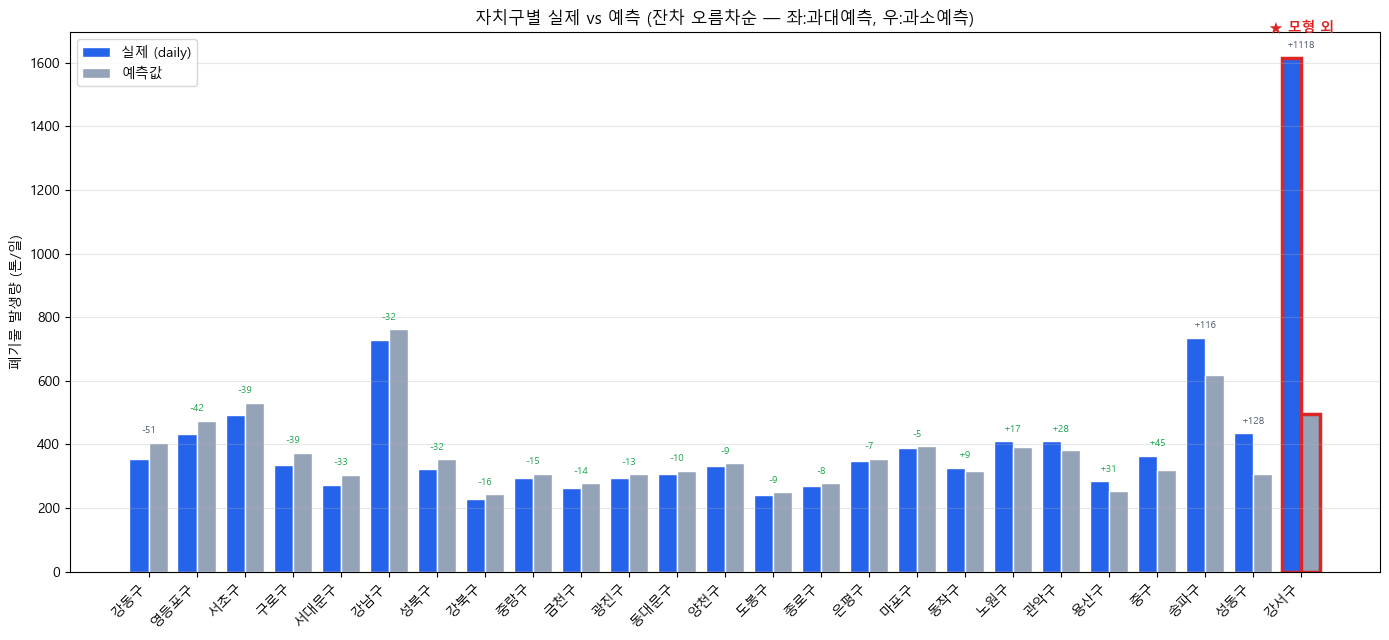

In [34]:
# 13-3. 자치구별 실제 vs 예측 paired 막대차트
df_plot = df_full.sort_values("잔차").reset_index(drop=True)
x = np.arange(len(df_plot))
w = 0.4

fig, ax = plt.subplots(figsize=(14, 6.5))
bars_act  = ax.bar(x - w/2, df_plot["daily"],   w, label="실제 (daily)",
                   color="#2563eb", edgecolor="white")
bars_pred = ax.bar(x + w/2, df_plot["예측값"], w, label="예측값",
                   color="#94a3b8", edgecolor="white")

# 강서구 강조
for i, gu in enumerate(df_plot["자치구"]):
    if gu == "강서구":
        bars_act[i].set_edgecolor("#dc2626")
        bars_act[i].set_linewidth(2.5)
        bars_pred[i].set_edgecolor("#dc2626")
        bars_pred[i].set_linewidth(2.5)
        ax.annotate("★ 모형 외",
                    xy=(i, df_plot.loc[i, "daily"]),
                    xytext=(i, df_plot.loc[i, "daily"] + 80),
                    ha="center", color="#dc2626", fontweight="bold", fontsize=10)

# 잔차 라벨
for i, r in df_plot.iterrows():
    top = max(r["daily"], r["예측값"])
    sign = "+" if r["잔차"] >= 0 else ""
    ax.text(i, top + 30, f"{sign}{r['잔차']:.0f}",
            ha="center", fontsize=7,
            color="#16a34a" if abs(r["잔차"]) < 50 else "#475569")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["자치구"], rotation=45, ha="right")
ax.set_ylabel("폐기물 발생량 (톤/일)")
ax.set_title("자치구별 실제 vs 예측 (잔차 오름차순 — 좌:과대예측, 우:과소예측)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

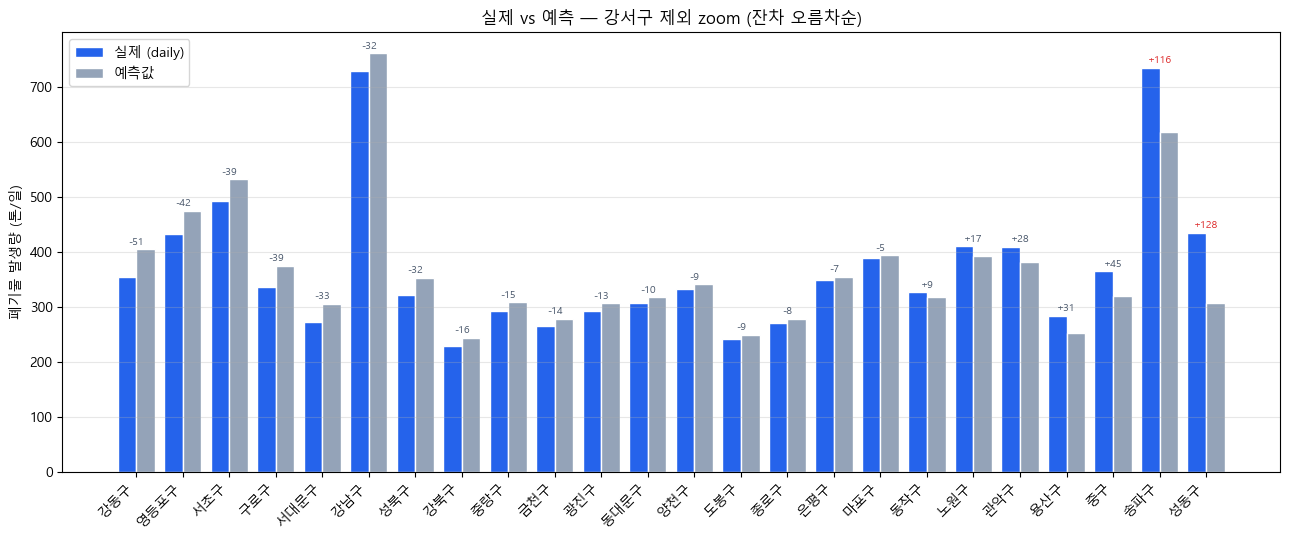


📊 요약: 24개 자치구 중 |잔차|<50톤 21개,
   |잔차|>100톤 2개 (모형 적합 한계 영역)


In [35]:
# 13-3b. 강서구 제외 zoom — 일반 자치구 차이가 묻히지 않도록
df_plot2 = df_full[df_full["자치구"] != "강서구"].sort_values("잔차").reset_index(drop=True)
x = np.arange(len(df_plot2))
w = 0.4

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - w/2, df_plot2["daily"],  w, label="실제 (daily)", color="#2563eb", edgecolor="white")
ax.bar(x + w/2, df_plot2["예측값"], w, label="예측값",       color="#94a3b8", edgecolor="white")

for i, r in df_plot2.iterrows():
    top = max(r["daily"], r["예측값"])
    sign = "+" if r["잔차"] >= 0 else ""
    ax.text(i, top + 8, f"{sign}{r['잔차']:.0f}",
            ha="center", fontsize=7.5,
            color="#dc2626" if abs(r["잔차"]) > 100 else "#475569")

ax.set_xticks(x)
ax.set_xticklabels(df_plot2["자치구"], rotation=45, ha="right")
ax.set_ylabel("폐기물 발생량 (톤/일)")
ax.set_title("실제 vs 예측 — 강서구 제외 zoom (잔차 오름차순)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

n_small = int((df_plot2["잔차"].abs() < 50).sum())
n_big   = int((df_plot2["잔차"].abs() > 100).sum())
print(f"\n📊 요약: 24개 자치구 중 |잔차|<50톤 {n_small}개,")
print(f"   |잔차|>100톤 {n_big}개 (모형 적합 한계 영역)")